<a href="https://colab.research.google.com/github/sonali206/funnel_events/blob/main/funnel_events.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv("funnel_events_sample.csv")

# Convert timestamp into datetime format
data["timestamp"] = pd.to_datetime(data["timestamp"])

# Check the data
print(data.head())
print(data.info())

  user_id            step           timestamp
0    U026  signup_started 2026-07-20 03:52:00
1    U100    visited_site 2026-07-20 03:48:00
2    U068  signup_started 2026-07-20 03:47:00
3    U051  email_verified 2026-07-20 04:46:00
4    U115    visited_site 2026-07-20 03:54:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   user_id    542 non-null    object        
 1   step       542 non-null    object        
 2   timestamp  542 non-null    datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 12.8+ KB
None


In [6]:
stages = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

In [7]:
user_counts = []

for stage in stages:
    count = data[data["step"] == stage]["user_id"].nunique()
    user_counts.append(count)

print(user_counts)

[200, 150, 96, 52, 44]


In [8]:
conversion_rates = [None]

for i in range(1, len(user_counts)):
    rate = (user_counts[i] / user_counts[i - 1]) * 100
    conversion_rates.append(round(rate, 2))

result = pd.DataFrame({
    "Stage": stages,
    "Unique Users": user_counts,
    "Conversion Rate (%)": conversion_rates
})

print(result)

                Stage  Unique Users  Conversion Rate (%)
0        visited_site           200                  NaN
1      signup_started           150                75.00
2      details_filled            96                64.00
3      email_verified            52                54.17
4  purchase_completed            44                84.62


In [9]:
drops = []

for i in range(1, len(user_counts)):
    drop = user_counts[i - 1] - user_counts[i]
    drops.append(drop)

biggest_drop = max(drops)
drop_index = drops.index(biggest_drop) + 1

print("Biggest drop-off:")
print(stages[drop_index - 1], "->", stages[drop_index])
print("Users lost:", biggest_drop)

Biggest drop-off:
signup_started -> details_filled
Users lost: 54


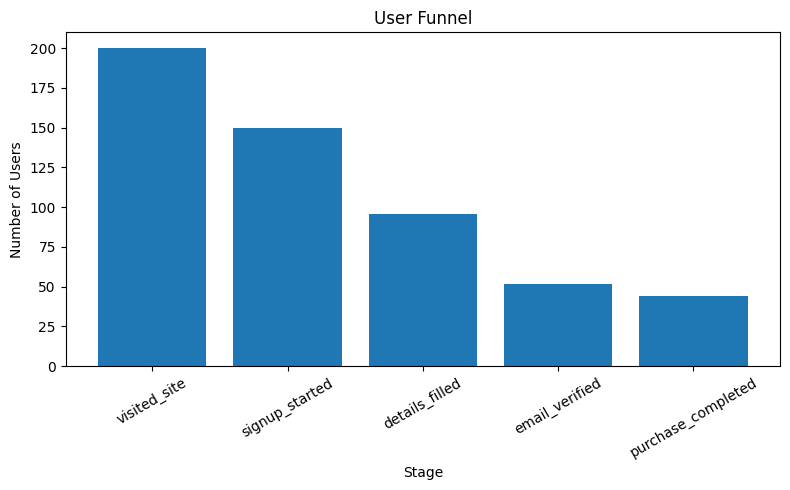

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(stages, user_counts)

plt.title("User Funnel")
plt.xlabel("Stage")
plt.ylabel("Number of Users")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [11]:
times = data.pivot_table(
    index="user_id",
    columns="step",
    values="timestamp",
    aggfunc="min"
)

for i in range(len(stages) - 1):

    first = stages[i]
    second = stages[i + 1]

    if first in times.columns and second in times.columns:

        users = times[[first, second]].dropna()

        time_taken = users[second] - users[first]

        if len(time_taken) > 0:
            average_time = time_taken.mean()

            print(
                first,
                "to",
                second,
                ":",
                average_time
            )

visited_site to signup_started : 0 days 00:15:49.600000
signup_started to details_filled : 0 days 00:17:05.217391304


Time-to-Convert

In [15]:
# Convert the data into one row per user
user_times = data.pivot_table(
    index="user_id",
    columns="step",
    values="timestamp",
    aggfunc="min"
)

# Calculate time between consecutive stages
for i in range(len(stages) - 1):

    first_stage = stages[i]
    next_stage = stages[i + 1]

    if first_stage in user_times.columns and next_stage in user_times.columns:

        users = user_times[[first_stage, next_stage]].dropna()

        if len(users) > 0:

            time_taken = (
                users[next_stage] - users[first_stage]
            )

            average_time = time_taken.mean()

            print(
                first_stage,
                "->",
                next_stage,
                ":",
                average_time
            )

        else:
            print(
                first_stage,
                "->",
                next_stage,
                ": No matching users"
            )

visited_site -> signup_started : 0 days 00:15:49.600000
signup_started -> details_filled : 0 days 00:17:05.217391304
details_filled -> email_verified : No matching users
email_verified -> purchase_completed : No matching users


Segment Comparison

In [17]:
# Create segments using the last digit of the user ID

data["Segment"] = data["user_id"].astype(str).apply(
    lambda x: "Even ID" if int(x[-1]) % 2 == 0 else "Odd ID"
)

# Count unique users in each stage
segment_counts = data.groupby(
    ["Segment", "step"]
)["user_id"].nunique().unstack(fill_value=0)

# Keep stages in funnel order
segment_counts = segment_counts.reindex(
    columns=stages,
    fill_value=0
)

print(segment_counts)

step     visited_site  signup_started  details_filled  email_verified  \
Segment                                                                 
Even ID           100              75              48              26   
Odd ID            100              75              48              26   

step     purchase_completed  
Segment                      
Even ID                  22  
Odd ID                   22  


In [18]:
# Calculate conversion rates for each segment

segment_conversion = segment_counts.copy()

for i in range(1, len(stages)):
    segment_conversion[stages[i]] = (
        segment_counts[stages[i]]
        / segment_counts[stages[i - 1]]
        * 100
    )

segment_conversion[stages[0]] = None

print(segment_conversion.round(2))

step    visited_site  signup_started  details_filled  email_verified  \
Segment                                                                
Even ID         None            75.0            64.0           54.17   
Odd ID          None            75.0            64.0           54.17   

step     purchase_completed  
Segment                      
Even ID               84.62  
Odd ID                84.62  


In [19]:
print(result)

                Stage  Unique Users  Conversion Rate (%)
0        visited_site           200                  NaN
1      signup_started           150                75.00
2      details_filled            96                64.00
3      email_verified            52                54.17
4  purchase_completed            44                84.62


conclusions

From this funnel analysis, I found that 200 users visited the site, but only 44 users completed the purchase. The biggest drop-off was between Signup Started and Details Filled, where 54 users were lost and the conversion rate was 64%. The average time taken from visiting the site to starting signup was around 15 minutes 50 seconds, and from signup started to details filled was around 17 minutes 5 seconds. I also compared Even ID and Odd ID users, but both segments showed the same conversion rates. Based on the results, I think simplifying the details form and using autofill or inline validation could help reduce user drop-off.